# Introduction

Analog computing promises a number of advantages over digital systems. For instance, digital systems require stable logic levels (0 or 1)
which remain stable for indefinite periods of time. In contrast, analog computing proposes to utilize the (potentially enormous) range of
values which can be held between these two stable poles, and harness the temporal dynamics inherent to many devices (electronic and otherwise).
A "classic" example is the crossbar architecture, in which the many-valued resistance levels of a device (such as a ReRAM element) can be used
to encode arbitrary real numbers (usually with a precision <= 6 bits). Currents traveling through the crossbar then inherently carry out a
matrix-vector multiplication through Kirchoff's current laws, multiplying each current through the resistor and summing it through a common,
per-column electrode.

However, this approach has numerous challenges. By discarding the stability of digital systems, analog systems require either careful calibration
to ensure all values converge onto their desired values, encoding schemes which can compensate for drift, or both. These systems can also be sensitive
to temperature, vibration, electromagnetic interference, manufacturing defects, device aging, etc.

However, we know of one very large scale analog computing system which can overcome these challenges to work across multiple decades. The brain
utilizes analog, electrochemical neurons to process and interact with information from the environment. It can do this processing in a way which
is both efficient and fits within the biological "power envelope" available to different animals, and responds on a time frame which is relevant
to the body (fastest actions on the order of millisecond, longest on the order of days/years).

As a result, the organization, representation, and manipulation of information within the brain has been a rich source of information for
artificial processing systems. Early characterizations of the neuron led to the development of the Hodgkin-Huxley model, which was simplified
into the integrate-and-fire model which can be analyzed in terms of simple firing rates. This "firing rate" interpetation gave rise to the
sum-and-transform model of the neuron which is still applied today in the multi-layer perceptrons that form the backbone of large language models.

However, in the meantime our understanding of the brain has greatly developed, due in part to large-scale recordings of neuronal ensembles rather
than isolated neurons. One almost universal characteristic observed through neural tissue has been the observation of waves of activity which
propagate through neural tissue, rather than spikes which appear across the tissue randomly. Activity is heavily localized around waves, and this
activity gives rise to the observed frequency bands of the brain (e.g. alpha, beta, gamma rhythms).

The motivation of the phase-based approach to neural networks - and computation in general - is what we explore in this notebook series, starting
with the neuron model which is the basis of this approach: the resonate-and-fire neuron.

*Phasor networks, from the ground up — notebook 1 of 6.*

This notebook builds the foundation: the **resonate-and-fire (R&F) neuron**, the
question of *what it stores*, and the **three faces of a phase** that fall out once
we measure it against a reference wave.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using PhasorNetworks
using Plots

  Activating project at `~/code/PhasorNetworks.jl`


## The resonate-and-fire neuron

An R&F neuron's complex membrane state `z` follows a single linear equation:

$$\frac{dz}{dt} = k\,z + I(t), \qquad k = \lambda + i\omega.$$

The eigenvalue `k` packs two numbers: the **decay** `λ < 0` (how fast a disturbance
fades) and the **carrier frequency** `ω = 2π/T` (how fast `z` rotates). Left alone,
`z` spirals inward; driven by input current `I(t)`, it rings. This is exactly the
Izhikevich resonate-and-fire model's subthreshold dynamics.

## Subthreshold ringing

The impulse response is the discrete kernel `K[n] = Aⁿ·B` with `A = exp(k·Δt)`,
`B = (A−1)/k` (`phasor_kernel`). A single kick sets the neuron ringing at `ω` while
decaying at `λ` — small `|λ|` rings for many cycles, large `|λ|` forgets quickly.

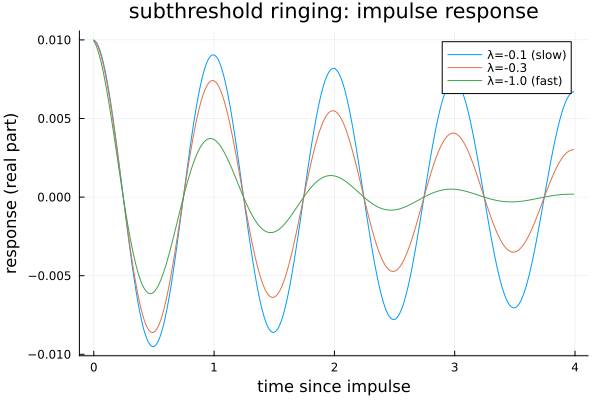

In [2]:
dt = 0.01f0; L = 400
lags = (0:L-1) .* dt
K = phasor_kernel(Float32[-0.1, -0.3, -1.0], Float32[2pi, 2pi, 2pi], dt, L)

plot(lags, real.(K)', label=["λ=-0.1 (slow)" "λ=-0.3" "λ=-1.0 (fast)"],
     xlabel="time since impulse", ylabel="response (real part)",
     title="subthreshold ringing: impulse response")

## Frequency preference (resonance)

Because it rings at `ω`, the neuron responds best to input that *arrives* at `ω`.
The steady-state response to a drive at frequency `Ω` is `|1/(iΩ − k)|`, a
Lorentzian peaked at the carrier frequency — the neuron is a tuned filter.

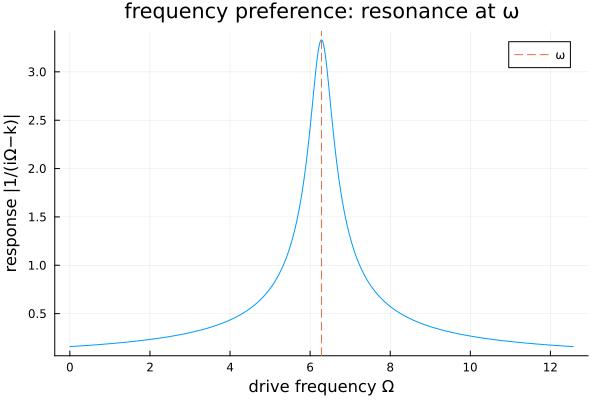

In [3]:
T = 1.0f0
omega = Float32(period_to_angfreq(T))
k = -0.3f0 + im * omega
Omega = range(0, 4pi, 400)
H = [1f0 / abs(im * Float32(o) - k) for o in Omega]

plot(Omega, H, label="", xlabel="drive frequency Ω", ylabel="response |1/(iΩ−k)|",
     title="frequency preference: resonance at ω")
vline!([omega], label="ω", linestyle=:dash)

The same preference shows up in the time domain. Drive a neuron with **two**
input spikes and sweep the gap between them: when the second arrives an integer
number of periods later it lands *in phase* and adds (large response); at a
half-period it lands *anti-phase* and cancels (back to a single-spike response).

(The model **detects** a spike when the membrane crosses threshold; it does not
*reset*, so it shows resonance and selective firing but not true bursting or
post-inhibitory rebound)

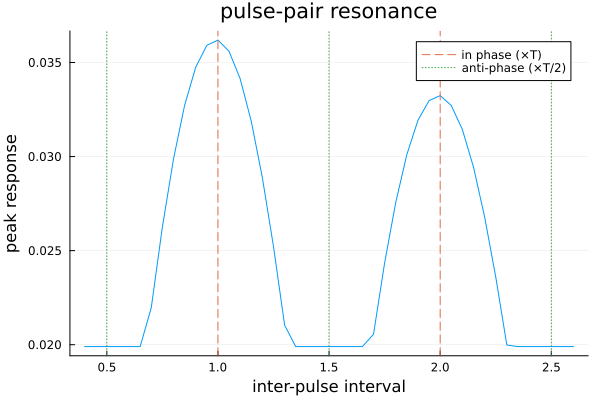

In [4]:
spk_args = SpikingArgs()            # T = 1, ω = 2π, λ = -0.2
period = spk_args.t_period

function pair_response(interval)
    t1 = 0.2f0; t2 = t1 + Float32(interval)
    st = SpikeTrain([CartesianIndex(1, 1), CartesianIndex(1, 1)], Float32[t1, t2], (1, 1), 0.0f0)
    sol = oscillator_bank(st, tspan=(0.0, Float64(t2) + 2.0), spk_args=spk_args)
    return maximum(abs.(Array(sol)[1, 1, :]))
end

intervals = 0.4:0.05:2.6
resp = [pair_response(i) for i in intervals]
plot(intervals, resp, label="", xlabel="inter-pulse interval", ylabel="peak response",
     title="pulse-pair resonance")
vline!([1.0, 2.0], label="in phase (×T)", linestyle=:dash)
vline!([0.5, 1.5, 2.5], label="anti-phase (×T/2)", linestyle=:dot)

## What does an R&F neuron store?

Not a firing **rate**: the neuron is pinned near its resonant frequency, so it
cannot freely encode a value as spikes-per-second. So what carries information?

The clue is in the dynamics. The state `z(t)` keeps rotating forever — its absolute
angle is never fixed. A lone oscillator, on its own, holds nothing we can read. The
missing ingredient is a **reference**.

## The reference wave

Give every neuron a shared **reference oscillator** at the same frequency `ω`. Then
the meaningful quantity is each neuron's angle *relative* to the reference,
`angle(z_ref · conj(z_j))` — the common `ω·t` rotation cancels and a **constant**
remains. That constant, readable at *any* time, is the phase the neuron stores.

First drive a bank of neurons, one per phase across `[-1, 1]`:

In [5]:
n_x = 101
phases = reshape(collect(range(-1.0, 1.0, n_x)), (:, 1))
repeats = 6
tspan = (0.0, repeats * 1.0)

st_bank = phase_to_train(phases, spk_args=spk_args, repeats=repeats, offset=0.0f0)
sol = oscillator_bank(st_bank, tspan=tspan, spk_args=spk_args)
u = Array(sol)
ts = sol.t
size(u)

(101, 1, 602)

Now measure three neurons against neuron 51 (the one encoding phase `0`). Each
neuron's **absolute** angle sweeps endlessly (left); its **relative** phase is flat
and constant, pinned at the value it encodes (right). *That* is what it holds.

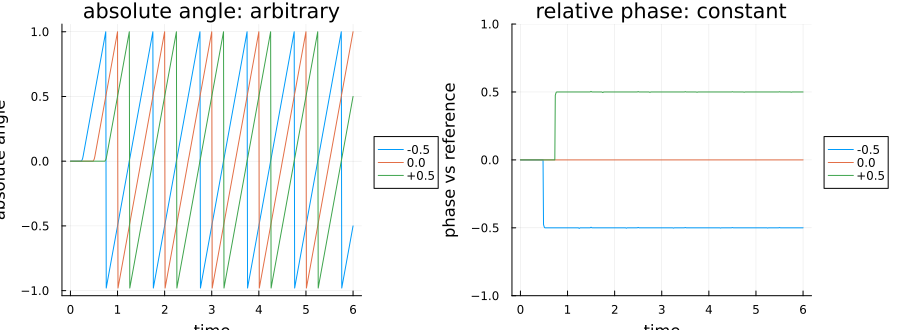

In [6]:
ref = u[51, 1, :]                     # reference oscillator (encodes phase 0)
sel = [26, 51, 76]                   # neurons encoding -0.5, 0.0, +0.5
lab = ["-0.5" "0.0" "+0.5"]

abs_ang = hcat([angle.(u[j, 1, :]) ./ pi for j in sel]...)
rel_ang = hcat([angle.(ref .* conj.(u[j, 1, :])) ./ pi for j in sel]...)

p_abs = plot(ts, abs_ang, label=lab, xlabel="time", ylabel="absolute angle",
             title="absolute angle: arbitrary", legend=:outerright)
p_rel = plot(ts, rel_ang, label=lab, xlabel="time", ylabel="phase vs reference",
             title="relative phase: constant", legend=:outerright, ylims=(-1, 1))
plot(p_abs, p_rel, layout=(1, 2), size=(900, 330))

## The three faces of a phase

The phase a neuron holds against the reference can be written three equivalent
ways — the same value, three faces:

| face | representation | lives in |
|------|----------------|----------|
| **point on the unit circle** | `exp(iπθ)` | the complex plane |
| **real angle** | `θ ∈ [-1, 1]` (units of π) | the real line |
| **spike time** | *when* the neuron fires in a cycle | time |

### Face 1 — a point on the unit circle

`angle_to_complex(θ)` maps a phase to `exp(iπθ)` (`θ=0→1`, `0.5→i`, `±1→-1`).

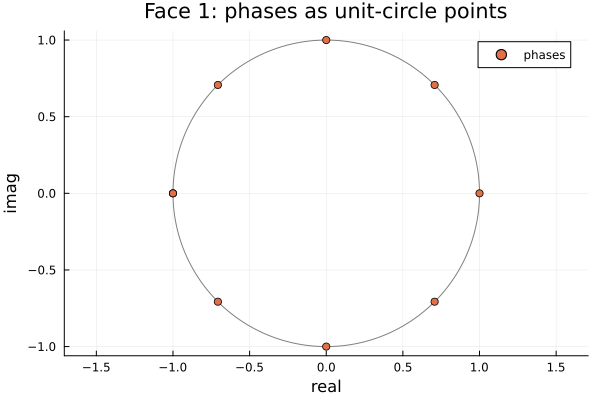

In [7]:
thetas = Float32.(range(-1, 1, 9))
z = angle_to_complex(thetas)

circ = exp.(im .* range(0, 2pi, 200))
plot(real.(circ), imag.(circ), label="", color=:gray, aspect_ratio=:equal)
scatter!(real.(z), imag.(z), label="phases", xlabel="real", ylabel="imag",
         title="Face 1: phases as unit-circle points")

This representation allows us to do calculation, analysis, and operations in the complex plane. However, storing and communicating a complex state is expensive - it requires either a complex value, or a two-vector of real values. 

### Face 2 — a real angle

If we are only concerned with the phase of a wave calculated in the complex plane, we can represent it more simply, by an angle.
Stripped of the complex plane, a phase is just a number in `[-1, 1]`. `complex_to_angle` reads it back off the circle.

In [8]:
recovered = complex_to_angle(z)
println("original θ : ", thetas)
println("recovered  : ", Float32.(recovered))

original θ : Float32[-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0]
recovered  : Float32[0.99999994, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, -0.99999994]


If we want to make a wave which reproduces a given phase angle, we can also represent it in another way: with a sparse, temporal pulse or "spike."

### Face 3 — a spike time

Encode a phase as the *time* a neuron fires in a cycle: `-1` at the start, `+1` at the end. `phase_to_train` builds the spikes; `train_to_phase` reads them back.

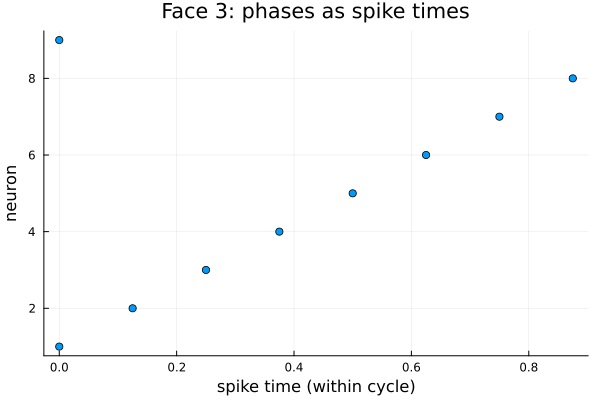

In [9]:
ph = reshape(thetas, (:, 1))
train = phase_to_train(ph, spk_args=spk_args, repeats=1)
neuron = getindex.(train.indices, 1)
scatter(train.times, neuron, label="", xlabel="spike time (within cycle)",
        ylabel="neuron", title="Face 3: phases as spike times")

All three faces interconvert. Round-trip a phase angle → spike time → angle:

In [10]:
t = phase_to_time(ph, spk_args=spk_args)
back = time_to_phase(vec(t), spk_args=spk_args, offset=0.0)
println("angle in : ", vec(ph))
println("angle out: ", Float32.(vec(back)))

angle in : Float32[-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0]
angle out: Float32[-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, -1.0]


## Banks can encode and decode whole vectors

The bank we drove above holds one phase per neuron. Reading it back through the
spike face — `solution_to_train` then `train_to_phase` — recovers every input phase
to within the spike-time resolution: the round trip *spike → oscillator → spike →
phase* is faithful.

max arc error: 0.9999690981897007


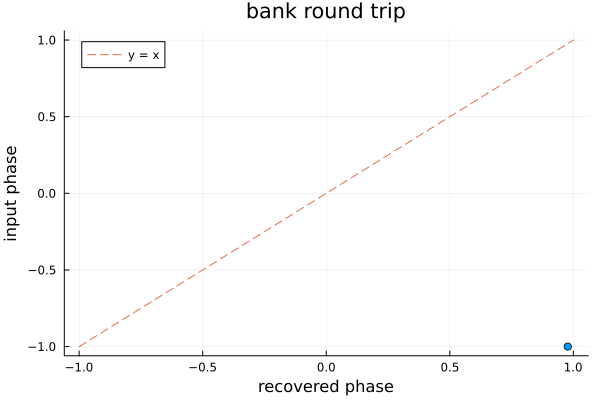

In [11]:
st1 = solution_to_train(sol, tspan, spk_args=spk_args, offset=0.0)
p1 = train_to_phase(st1, spk_args=spk_args)

rec = p1[end-1, :, 1]
err = arc_error(rec .- vec(phases))
println("max arc error: ", maximum(err))

scatter(rec, vec(phases), xlabel="recovered phase", ylabel="input phase",
        label="", title="bank round trip")
plot!(-1:1, -1:1, label="y = x", linestyle=:dash)

## Where this leads

A *vector* of these phases is exactly a symbol in the FHRR hyperdimensional
computing model. And the neuron's own update is already two HD operations:

$$\frac{dz}{dt} = \underbrace{k\,z}_{\text{bind to self (rotation)}} + \underbrace{W\,I(t)}_{\text{bundle inputs (superposition)}}.$$

The `k·z` term *rotates* the neuron's own state; the `W·I(t)` term *superposes* its
inputs. The next notebook makes these two operations — and similarity — explicit,
and shows that connecting oscillators this way reproduces the full FHRR algebra.

## Next

Notebook 2: **HD operations** — similarity, bundling, and binding, by superposition
and rotation of connected oscillators.